# MNIST 분류 모델 구현
이 노트북은 TensorFlow/Keras를 사용하여 MNIST 데이터셋을 학습하고 평가하는 모델을 구현합니다.

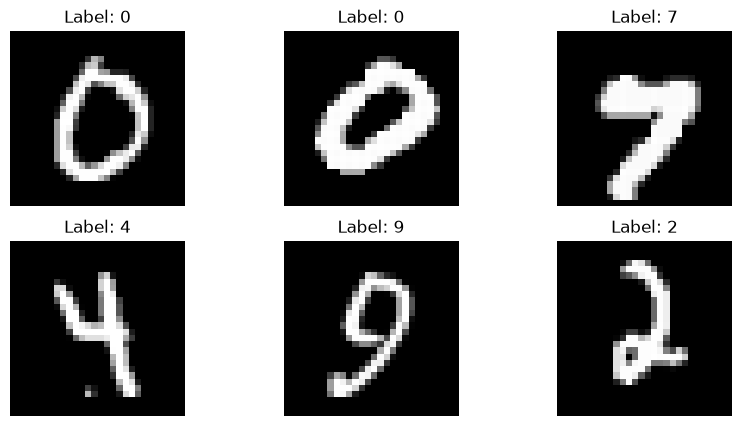

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 전처리
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 샘플 이미지 6개 출력
plt.figure(figsize=(10, 5))
for i in range(6):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')
plt.show()

In [2]:
# 2. 모델 설계
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. EarlyStopping 적용
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

d:\hvyrain-ysc\deeplearning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9069 - loss: 0.3215 - val_accuracy: 0.9548 - val_loss: 0.1566
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9541 - loss: 0.1546 - val_accuracy: 0.9666 - val_loss: 0.1152
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9660 - loss: 0.1164 - val_accuracy: 0.9716 - val_loss: 0.1004
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9706 - loss: 0.0945 - val_accuracy: 0.9717 - val_loss: 0.0984
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9752 - loss: 0.0800 - val_accuracy: 0.9746 - val_loss: 0.0915
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9782 - loss: 0.0700 - val_accuracy: 0.9764 - val_loss: 0.0878
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0594 - val_accuracy: 0.9769 - val_loss: 0.0838
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0521 - 

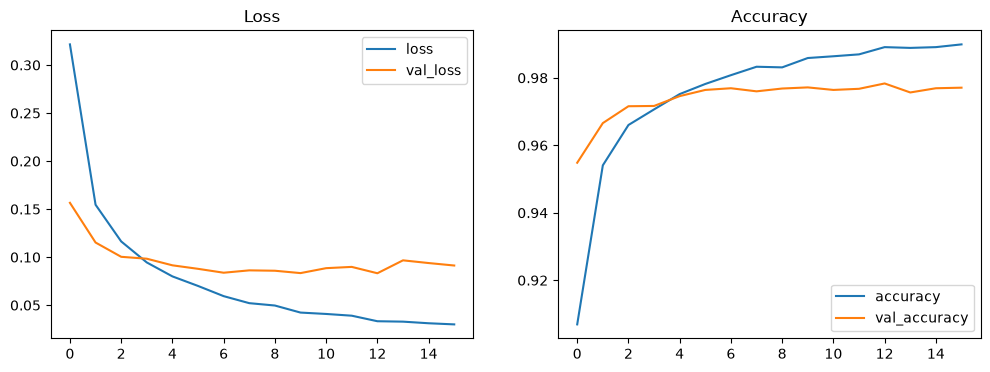

In [3]:
# 4. 학습 및 시각화
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stopping])

plt.figure(figsize=(12, 4))

# Loss 차트
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

# Accuracy 차트
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [4]:
# 5. 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\n테스트 정확도: {test_acc:.4f}, 테스트 손실: {test_loss:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.9781 - loss: 0.0785

테스트 정확도: 0.9781, 테스트 손실: 0.0785
